# Mental Health GraphRAG Pipeline — v2

**Workflow:**
1. Configure your LLM (local Ollama or cloud)
2. Load & parse markdown documents
3. Enrich nodes with context (resumable, auto-saved)
4. Extract knowledge graph triplets (resumable, auto-saved)
5. Load final checkpoints
6. Community detection (Leiden)
7. Community summarization
8. Query engine (local + global + hybrid)
9. Visualization

> **TIP — Local models (Ollama):** Steps 3 and 4 can take a long time. Each cell auto-saves progress after every node. If interrupted, just re-run the cell and it picks up where it left off.

---
## Step 0 — Configuration
Set your model here **once**. All subsequent steps will use this `llm` object.

In [25]:
import os
from dotenv import load_dotenv

load_dotenv()

# ─────────────────────────────────────────────────────────────────────────────
# MODEL SELECTION — uncomment ONE block below
# ─────────────────────────────────────────────────────────────────────────────

# ── OPTION A: Ollama (LOCAL) ──────────────────────────────────────────────────
# Runs entirely on your machine. No API key needed. Requires Ollama to be
# running: https://ollama.com  →  `ollama serve`
#
# Recommended models (pull first with `ollama pull <name>`):
#   Fast / light : "phi3", "gemma2:2b", "qwen2:1.5b"
#   Balanced     : "llama3", "mistral", "gemma2", "qwen2"
#   High quality : "llama3.1", "mixtral", "deepseek-r1:8b"
#
# from llama_index.llms.ollama import Ollama
# llm = Ollama(model="qwen3.5:0.8b", request_timeout=300.0)


# ── OPTION B: Ollama (CLOUD / REMOTE SERVER) ─────────────────────────────────
# Use Ollama running on a remote machine (cloud VM, server, etc.).
#
# Setup:
#   1. Set OLLAMA_CLOUD_URL in your .env  (e.g.  OLLAMA_CLOUD_URL=http://1.2.3.4:11434)
#      OR replace the fallback URL string below with your server address.
#   2. Set the model name to one that is already pulled on the remote server.
#      ⚠️  Ollama model tags are size variants like :7b, :14b, :latest — NOT ":cloud"
#
# Examples of valid model names for a remote server:
#   "llama3"          (= llama3:latest)
#   "llama3.1:8b"
#   "qwen2.5:7b"
#   "mistral:7b"
#   "deepseek-r1:8b"
#
from llama_index.llms.ollama import Ollama
llm = Ollama(
    model="glm-4.7:cloud",                                                         # ← change to your remote model
    base_url=os.getenv("OLLAMA_CLOUD_URL", "http://your-server-ip:11434"), # ← set OLLAMA_CLOUD_URL in .env
    request_timeout=300.0,
)


# ── OPTION C: OpenAI (CLOUD) ──────────────────────────────────────────────────
# Requires OPENAI_API_KEY in your .env file.
#
# Models:
#   Fast / cheap : "gpt-4o-mini"
#   High quality : "gpt-4o"
#
# from llama_index.llms.openai import OpenAI
# llm = OpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY"))


# ── OPTION D: Anthropic Claude (CLOUD) ───────────────────────────────────────
# Requires ANTHROPIC_API_KEY in your .env file.
#
# Models:
#   Fast / cheap : "claude-3-haiku-20240307"
#   High quality : "claude-3-5-sonnet-20241022"
#
# from llama_index.llms.anthropic import Anthropic
# llm = Anthropic(model="claude-3-haiku-20240307", api_key=os.getenv("ANTHROPIC_API_KEY"))


# ── OPTION E: Google Gemini (CLOUD) ──────────────────────────────────────────
# Requires GOOGLE_API_KEY in your .env file.
#
# Models:
#   Fast / cheap : "models/gemini-1.5-flash"
#   High quality : "models/gemini-1.5-pro"
#
# from llama_index.llms.gemini import Gemini
# llm = Gemini(model="models/gemini-1.5-flash", api_key=os.getenv("GOOGLE_API_KEY"))


# ─────────────────────────────────────────────────────────────────────────────
print(f"✅ LLM configured: {llm.__class__.__name__}")

✅ LLM configured: Ollama


In [2]:
# test the LLM with a simple prompt
response = llm.complete("What is 2+2?")
print(f"LLM response test: {response}")

LLM response test: 2 + 2 is 4.


---
## Step 1 — Load & Parse Markdown Documents

In [3]:
from llama_index.core import SimpleDirectoryReader
from llama_index.core.node_parser import MarkdownNodeParser

# 1. Load markdown files from the data folder
reader = SimpleDirectoryReader(input_dir="./data/markdown",required_exts=[".md"])
documents = reader.load_data()

# 2. Split by markdown headers (## / ###) — preserves logical sections
parser = MarkdownNodeParser()
nodes = parser.get_nodes_from_documents(documents)

print(f"--- Division Complete ---")
print(f"Total logical sections found: {len(nodes)}\n")

for i, node in enumerate(nodes[:3]):
    header = node.metadata.get("header_path", "Main Title")
    print(f"SECTION {i}: {header}")
    print(f"TEXT PREVIEW: {node.text[:100]}...")
    print("-" * 30)

--- Division Complete ---
Total logical sections found: 164

SECTION 0: /
TEXT PREVIEW: An illustration shows a person lying in bed, covering their face with their hands, with a scribbled ...
------------------------------
SECTION 1: /
TEXT PREVIEW: ## Is it stress or anxiety?

<table>
  <tbody>
    <tr>
        <td>Stress</td>
        <td>Bo...
------------------------------
SECTION 2: /
TEXT PREVIEW: ## Ways to Cope
* Keep a journal.
* Download an app with relaxation exercises.
* Exercise and eat...
------------------------------


---
## Step 2 — Node Enrichment (Contextual Tagging)

Each node gets a 1-sentence context tag so the graph knows which disorder and sub-topic it belongs to.

> **Progress is auto-saved** after every node into `./checkpoints/enrichment_progress.jsonl`.  
> If interrupted, re-run **2a → 2b → 2c** and it will continue from the last saved node.

### 2a — Check Progress

In [4]:
import json
import os

ENRICHMENT_PROGRESS_FILE = "./checkpoints/enrichment_progress.jsonl"
os.makedirs("./checkpoints", exist_ok=True)

# Auto-detect how many nodes are already processed
already_enriched = 0
if os.path.exists(ENRICHMENT_PROGRESS_FILE):
    with open(ENRICHMENT_PROGRESS_FILE, "r", encoding="utf-8") as f:
        already_enriched = sum(1 for line in f if line.strip())
    print(f"Progress file found: {already_enriched} / {len(nodes)} nodes already enriched.")
else:
    print("No progress file found. Will start from scratch.")

# ─────────────────────────────────────────────────────────────────────────────
# RESUME CONTROL
# Leave as None  → auto-resume from last saved position
# Set to 0       → restart from the very beginning (overwrites previous progress)
# Set to N (int) → start from node index N
# ─────────────────────────────────────────────────────────────────────────────
ENRICH_START_INDEX = None  # <── change if needed

if ENRICH_START_INDEX is None:
    ENRICH_START_INDEX = already_enriched

if ENRICH_START_INDEX == 0 and os.path.exists(ENRICHMENT_PROGRESS_FILE):
    os.remove(ENRICHMENT_PROGRESS_FILE)
    print("⚠️  Restart requested — progress file cleared.")

print(f"\n─── Enrichment will START from index : {ENRICH_START_INDEX}")
print(f"─── Nodes remaining                  : {len(nodes) - ENRICH_START_INDEX}")

Progress file found: 164 / 164 nodes already enriched.

─── Enrichment will START from index : 164
─── Nodes remaining                  : 0


### 2b — Run Enrichment Loop
Each enriched node is **immediately appended** to the progress file.

In [5]:
print(f"Starting enrichment from node {ENRICH_START_INDEX} / {len(nodes) - 1}...\n")

with open(ENRICHMENT_PROGRESS_FILE, "a", encoding="utf-8") as progress_f:
    for i in range(ENRICH_START_INDEX, len(nodes)):
        node = nodes[i]
        source_doc = node.metadata.get("file_name", "Unknown Document")

        prompt = f"""
        Below is a section from a mental health brochure titled '{source_doc}'. 
        Please provide a 1-sentence context that describes what disorder and what sub-topic 
        (e.g., Symptoms, Treatment, Causes) this text belongs to. 
        
        TEXT: {node.text[:500]}...
        
        Output only the context sentence and nothing else.
        """

        context_tag = llm.complete(prompt).text.strip()
        enriched_text = f"[CONTEXT: {context_tag}]\n\n" + node.text

        # Save this node's result immediately
        record = {"idx": i, "text": enriched_text}
        progress_f.write(json.dumps(record, ensure_ascii=False) + "\n")
        progress_f.flush()  # force write to disk right away

        print(f"[{i+1}/{len(nodes)}] Enriched: {context_tag[:70]}...")

print(f"\n✅ Enrichment loop finished. Progress saved to {ENRICHMENT_PROGRESS_FILE}")

Starting enrichment from node 164 / 163...


✅ Enrichment loop finished. Progress saved to ./checkpoints/enrichment_progress.jsonl


### 2c — Finalize Enrichment → Save to PKL
Run this **once** when all nodes are enriched. Reconstructs the nodes list and saves a final checkpoint.

In [6]:
import pickle
import json

# Load all saved enriched texts from the progress file
enriched_texts = {}
with open(ENRICHMENT_PROGRESS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            record = json.loads(line)
            enriched_texts[record["idx"]] = record["text"]

if len(enriched_texts) < len(nodes):
    missing = len(nodes) - len(enriched_texts)
    print(f"⚠️  Warning: {missing} node(s) not yet enriched. Run Step 2b first.")
else:
    # Apply enriched texts back to a copy of the nodes list
    enriched_nodes = []
    for i, node in enumerate(nodes):
        if i in enriched_texts:
            node.text = enriched_texts[i]
        enriched_nodes.append(node)

    with open("./checkpoints/enriched_nodes.pkl", "wb") as f:
        pickle.dump(enriched_nodes, f)

    print(f"✅ All {len(enriched_nodes)} enriched nodes saved to ./checkpoints/enriched_nodes.pkl")
    print(f"   Step 2 is COMPLETE — you can skip to Step 4 next time.")

✅ All 164 enriched nodes saved to ./checkpoints/enriched_nodes.pkl
   Step 2 is COMPLETE — you can skip to Step 4 next time.


---
## Step 3 — Graph Construction (Triplet Extraction)

For each enriched node, the LLM extracts structured medical triplets  
`(Subject : Type) -[RELATION]-> (Object : Type)`.

> **Progress is auto-saved** after every node into `./checkpoints/graph_progress.jsonl`.  
> If interrupted, re-run **3a → 3b → 3c**.

### 3a — Check Progress

In [16]:
import json
import os

GRAPH_PROGRESS_FILE = "./checkpoints/graph_progress.jsonl"
os.makedirs("./checkpoints", exist_ok=True)

# Auto-detect how many nodes are already processed
already_graph_nodes = 0
pre_loaded_entities = 0
pre_loaded_relations = 0

if os.path.exists(GRAPH_PROGRESS_FILE):
    with open(GRAPH_PROGRESS_FILE, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                record = json.loads(line)
                already_graph_nodes += 1
                pre_loaded_entities += len(record.get("entities", []))
                pre_loaded_relations += len(record.get("relations", []))
    print(
        f"Progress file found: {already_graph_nodes} / {len(enriched_nodes)} nodes processed, "
        f"{pre_loaded_entities} entities and {pre_loaded_relations} relations accumulated."
    )
else:
    print("No graph progress file found. Will start from scratch.")

# RESUME CONTROL
# Leave as None  -> auto-resume from last saved position
# Set to 0       -> restart from the very beginning (overwrites previous progress)
# Set to N (int) -> start from node index N
GRAPH_START_INDEX = None  # change if needed

if GRAPH_START_INDEX is None:
    GRAPH_START_INDEX = already_graph_nodes

if GRAPH_START_INDEX == 0 and os.path.exists(GRAPH_PROGRESS_FILE):
    os.remove(GRAPH_PROGRESS_FILE)
    print("Restart requested - graph progress file cleared.")

print(f"\nGraph extraction will START from index: {GRAPH_START_INDEX}")
print(f"Nodes remaining                       : {len(enriched_nodes) - GRAPH_START_INDEX}")

Progress file found: 164 / 164 nodes processed, 1025 entities and 788 relations accumulated.

Graph extraction will START from index: 164
Nodes remaining                       : 0


### 3b — Run Extraction Loop
Each node's triplets are **immediately appended** to the progress file.

In [15]:
import re
import json
from llama_index.core.llms import ChatMessage

# Advanced Graph Builder V4 extraction prompt
extraction_prompt = """
You are a medical knowledge graph extractor for mental health literature.

Return VALID JSON ONLY with this exact structure:
{
  "entities": [
    {"id": "n0", "name": "DEPRESSION", "type": "CONDITION", "description": "..."}
  ],
  "relations": [
    {"source": "n0", "target": "n1", "relation": "HAS_SYMPTOM", "description": "...", "strength": 7}
  ]
}

Rules:
- Use only these entity types: CONDITION, SYMPTOM, TREATMENT, MEDICATION, SAFETY_RESOURCE, DEMOGRAPHIC.
- Use only these relation labels: HAS_SYMPTOM, TREATED_BY, PRESCRIBES, SUITABLE_FOR, CONTRAINDICATED_FOR, URGENT_ACTION.
- "source" and "target" must reference entity ids from the entities list.
- If nothing meaningful exists, return {"entities": [], "relations": []}.
- Do not return markdown, prose, or code fences.
"""

print(f"Starting graph extraction from node {GRAPH_START_INDEX} / {len(enriched_nodes) - 1}...\n")

with open(GRAPH_PROGRESS_FILE, "a", encoding="utf-8") as progress_f:
    for i in range(GRAPH_START_INDEX, len(enriched_nodes)):
        node = enriched_nodes[i]

        system_msg = ChatMessage(role="system", content=extraction_prompt)
        user_msg = ChatMessage(role="user", content=f"Extract from this text:\n\n{node.text}")
        response = llm.chat([system_msg, user_msg]).message.content.strip()

        response = re.sub(r"^```(?:json)?\s*", "", response)
        response = re.sub(r"\s*```$", "", response)

        parsed = {"entities": [], "relations": []}
        parse_error = None
        try:
            if response:
                raw = json.loads(response)
                if isinstance(raw, dict):
                    entities = raw.get("entities", [])
                    relations = raw.get("relations", raw.get("triplets", []))
                else:
                    entities, relations = [], []

                if not isinstance(entities, list):
                    entities = []
                if not isinstance(relations, list):
                    relations = []

                parsed = {"entities": entities, "relations": relations}
        except Exception as e:
            parse_error = str(e)

        record = {
            "node_idx": i,
            "entities": parsed.get("entities", []),
            "relations": parsed.get("relations", []),
            "parse_error": parse_error,
        }
        progress_f.write(json.dumps(record, ensure_ascii=False) + "\n")
        progress_f.flush()

        if parse_error:
            print(f"[{i+1}/{len(enriched_nodes)}] parse_error: {parse_error[:80]}")
        else:
            print(
                f"[{i+1}/{len(enriched_nodes)}] "
                f"entities={len(record['entities'])}, relations={len(record['relations'])}"
            )

print(f"\nGraph extraction loop finished. Progress saved to {GRAPH_PROGRESS_FILE}")

Starting graph extraction from node 0 / 163...

[1/164] entities=2, relations=1
[2/164] entities=9, relations=14
[3/164] entities=9, relations=8
[4/164] entities=4, relations=4
[5/164] entities=1, relations=0
[6/164] entities=4, relations=3
[7/164] entities=23, relations=22
[8/164] entities=2, relations=1
[9/164] entities=17, relations=2
[10/164] entities=10, relations=7
[11/164] entities=7, relations=6
[12/164] entities=4, relations=3
[13/164] entities=10, relations=9
[14/164] entities=13, relations=9
[15/164] entities=4, relations=3
[16/164] entities=4, relations=3
[17/164] entities=0, relations=0
[18/164] entities=0, relations=0
[19/164] entities=0, relations=0
[20/164] entities=6, relations=5
[21/164] entities=14, relations=13
[22/164] entities=5, relations=3
[23/164] entities=2, relations=0
[24/164] entities=10, relations=0
[25/164] entities=6, relations=1
[26/164] entities=7, relations=1
[27/164] entities=15, relations=14
[28/164] entities=7, relations=5
[29/164] entities=5, rela

### 3c — Finalize Graph → Save to PKL
Run this **once** when all nodes are processed.

In [17]:
import pickle
import json
import os
from llama_index.core.graph_stores.types import EntityNode, Relation

# Fallback helper definitions so this cell runs even if advanced utility cells were not executed yet.
if "ABBREVIATION_MAP" not in globals():
    ABBREVIATION_MAP = {
        "CBT": "COGNITIVE BEHAVIORAL THERAPY",
        "DBT": "DIALECTICAL BEHAVIOR THERAPY",
        "ACT": "ACCEPTANCE AND COMMITMENT THERAPY",
        "EMDR": "EYE MOVEMENT DESENSITIZATION AND REPROCESSING",
        "ECT": "ELECTROCONVULSIVE THERAPY",
        "TMS": "TRANSCRANIAL MAGNETIC STIMULATION",
        "SSRI": "SELECTIVE SEROTONIN REUPTAKE INHIBITOR",
        "SNRI": "SEROTONIN NOREPINEPHRINE REUPTAKE INHIBITOR",
        "TCA": "TRICYCLIC ANTIDEPRESSANT",
        "MAOI": "MONOAMINE OXIDASE INHIBITOR",
        "MDD": "MAJOR DEPRESSIVE DISORDER",
        "GAD": "GENERALIZED ANXIETY DISORDER",
        "PTSD": "POST TRAUMATIC STRESS DISORDER",
        "OCD": "OBSESSIVE COMPULSIVE DISORDER",
        "BPD": "BORDERLINE PERSONALITY DISORDER",
        "ADHD": "ATTENTION DEFICIT HYPERACTIVITY DISORDER",
        "SAD": "SEASONAL AFFECTIVE DISORDER",
        "ASD": "AUTISM SPECTRUM DISORDER",
    }

if "TYPE_PRIORITY" not in globals():
    TYPE_PRIORITY = {
        "CONDITION": 6,
        "MEDICATION": 5,
        "TREATMENT": 4,
        "SYMPTOM": 3,
        "DEMOGRAPHIC": 2,
        "SAFETY_RESOURCE": 1,
    }

if "VALID_SUBJECT_RELATIONS" not in globals():
    VALID_SUBJECT_RELATIONS = {
        ("CONDITION", "HAS_SYMPTOM"),
        ("CONDITION", "TREATED_BY"),
        ("CONDITION", "SUITABLE_FOR"),
        ("CONDITION", "CONTRAINDICATED_FOR"),
        ("CONDITION", "URGENT_ACTION"),
        ("MEDICATION", "PRESCRIBES"),
        ("MEDICATION", "SUITABLE_FOR"),
        ("MEDICATION", "CONTRAINDICATED_FOR"),
        ("TREATMENT", "SUITABLE_FOR"),
        ("TREATMENT", "CONTRAINDICATED_FOR"),
        ("DEMOGRAPHIC", "SUITABLE_FOR"),
        ("DEMOGRAPHIC", "CONTRAINDICATED_FOR"),
        ("SAFETY_RESOURCE", "SUITABLE_FOR"),
        ("SAFETY_RESOURCE", "URGENT_ACTION"),
        ("SYMPTOM", "URGENT_ACTION"),
    }

if "GARBAGE_FRAGMENTS" not in globals():
    GARBAGE_FRAGMENTS = {
        "COMBINATION", "VARIOUS", "MULTIPLE", "SEVERAL",
        "LIFELONG", "ONGOING", "CONTINUED", "ADDITIONAL",
        "APPROACH", "APPROACHES", "OPTION", "OPTIONS",
        "STRATEGY", "STRATEGIES", "PROGRAM", "PROGRAMS",
        "INTERVENTION", "INTERVENTIONS", "MANAGEMENT",
        "SUPPORT", "SERVICES", "CARE", "HELP",
    }

if "_STOP_WORDS" not in globals():
    _STOP_WORDS = {"OF", "AND", "OR", "THE", "A", "AN", "WITH", "FOR", "IN", "TO"}

if "singularize" not in globals():
    def singularize(name: str) -> str:
        if name.endswith("IES") and len(name) > 4:
            return name[:-3] + "Y"
        if name.endswith("SSES"):
            return name[:-2]
        if name.endswith("S") and not name.endswith("SS") and len(name) > 4:
            exceptions = {
                "STRESS", "AIDS", "CRISIS", "DIAGNOSIS", "PSYCHOSIS", "NEUROSIS", "PROGNOSIS", "THESIS", "BASIS"
            }
            if name not in exceptions:
                return name[:-1]
        return name

if "canonicalize" not in globals():
    def canonicalize(name: str) -> str:
        name = name.strip().upper()
        name = name.replace("-", " ").replace("_", " ")
        name = " ".join(name.split())
        name = ABBREVIATION_MAP.get(name, name)
        return singularize(name)

if "resolve_type" not in globals():
    def resolve_type(existing_type: str, new_type: str) -> str:
        return existing_type if TYPE_PRIORITY.get(existing_type, 0) >= TYPE_PRIORITY.get(new_type, 0) else new_type

if "is_garbage_entity" not in globals():
    def is_garbage_entity(name: str) -> bool:
        words = set(name.upper().split()) - _STOP_WORDS
        if not words:
            return True
        if words.issubset(GARBAGE_FRAGMENTS):
            return True
        if len(words) <= 2 and words & GARBAGE_FRAGMENTS:
            return True
        return False

if "is_valid_relation" not in globals():
    def is_valid_relation(subj_type: str, relation: str) -> bool:
        return (subj_type, relation) in VALID_SUBJECT_RELATIONS

ALLOWED_TYPES = {
    "CONDITION", "SYMPTOM", "TREATMENT", "MEDICATION", "SAFETY_RESOURCE", "DEMOGRAPHIC"
}
ALLOWED_RELATIONS = {
    "HAS_SYMPTOM", "TREATED_BY", "PRESCRIBES", "SUITABLE_FOR", "CONTRAINDICATED_FOR", "URGENT_ACTION"
}

if not os.path.exists(GRAPH_PROGRESS_FILE):
    print("graph_progress.jsonl not found. Run Step 3b first.")
else:
    custom_entities = {}
    entity_id_to_node = {}
    entity_descriptions = {}
    entity_sources = {}
    custom_relations = []
    relation_metadata = {}
    seen_relations = set()

    skipped_records = 0

    with open(GRAPH_PROGRESS_FILE, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue

            record = json.loads(line)
            node_idx = record.get("node_idx", -1)
            node_source_id = str(node_idx)

            local_id_map = {}

            entities = record.get("entities", [])
            if not isinstance(entities, list):
                entities = []
            for ent in entities:
                if not isinstance(ent, dict):
                    continue

                raw_name = str(ent.get("name", "")).strip()
                raw_type = str(ent.get("type", "")).strip().upper()
                local_id = str(ent.get("id", "")).strip()
                desc = str(ent.get("description", "")).strip()

                if not raw_name or not raw_type:
                    continue
                if raw_type not in ALLOWED_TYPES:
                    continue

                canon = canonicalize(raw_name)
                if is_garbage_entity(canon):
                    continue

                local_key = local_id if local_id else canon
                local_id_map[local_key] = canon

                if canon not in custom_entities:
                    node = EntityNode(
                        name=canon,
                        label=raw_type,
                        properties={"description": desc, "sources": [node_source_id]},
                    )
                    custom_entities[canon] = node
                    entity_id_to_node[node.id] = node
                    entity_descriptions[canon] = desc
                    entity_sources[canon] = {node_source_id}
                else:
                    existing = custom_entities[canon]
                    existing.label = resolve_type(existing.label, raw_type)
                    if len(desc) > len(entity_descriptions.get(canon, "")):
                        entity_descriptions[canon] = desc
                        existing.properties["description"] = desc
                    entity_sources.setdefault(canon, set()).add(node_source_id)
                    existing.properties["sources"] = list(entity_sources[canon])

            relations = record.get("relations", [])
            if not isinstance(relations, list):
                relations = []
            for rel in relations:
                if not isinstance(rel, dict):
                    continue

                src_ref = str(rel.get("source", rel.get("subject", ""))).strip()
                tgt_ref = str(rel.get("target", rel.get("object", ""))).strip()
                rel_label = str(rel.get("relation", rel.get("label", rel.get("predicate", "")))).strip().upper()
                rel_desc = str(rel.get("description", "")).strip()

                strength_raw = rel.get("strength", 5)
                try:
                    rel_strength = int(strength_raw)
                except Exception:
                    rel_strength = 5

                subj = local_id_map.get(src_ref)
                obj = local_id_map.get(tgt_ref)

                # Fallback: allow name-based references from model output.
                if not subj and src_ref:
                    src_canon = canonicalize(src_ref)
                    if src_canon in custom_entities:
                        subj = src_canon
                if not obj and tgt_ref:
                    tgt_canon = canonicalize(tgt_ref)
                    if tgt_canon in custom_entities:
                        obj = tgt_canon

                if not subj or not obj:
                    continue
                if rel_label not in ALLOWED_RELATIONS:
                    continue
                if subj not in custom_entities or obj not in custom_entities:
                    continue

                subj_type = custom_entities[subj].label
                if not is_valid_relation(subj_type, rel_label):
                    continue

                rel_key = (subj, rel_label, obj)
                if rel_key in seen_relations:
                    if rel_key in relation_metadata and rel_strength > relation_metadata[rel_key]["strength"]:
                        relation_metadata[rel_key]["strength"] = rel_strength
                    if rel_key in relation_metadata:
                        relation_metadata[rel_key]["sources"].add(node_source_id)
                    continue

                seen_relations.add(rel_key)
                relation = Relation(
                    source_id=custom_entities[subj].id,
                    target_id=custom_entities[obj].id,
                    label=rel_label,
                )
                custom_relations.append(relation)

                relation_metadata[rel_key] = {
                    "description": rel_desc,
                    "strength": rel_strength,
                    "sources": {node_source_id},
                }

            if record.get("parse_error"):
                skipped_records += 1

    with open("./checkpoints/custom_entities.pkl", "wb") as f:
        pickle.dump(custom_entities, f)
    with open("./checkpoints/entity_id_to_node.pkl", "wb") as f:
        pickle.dump(entity_id_to_node, f)
    with open("./checkpoints/custom_relations.pkl", "wb") as f:
        pickle.dump(custom_relations, f)
    with open("./checkpoints/entity_descriptions.pkl", "wb") as f:
        pickle.dump(entity_descriptions, f)
    with open("./checkpoints/entity_sources.pkl", "wb") as f:
        pickle.dump(entity_sources, f)

    relation_metadata_serializable = {
        str(k): {**v, "sources": list(v["sources"])}
        for k, v in relation_metadata.items()
    }
    with open("./checkpoints/relation_metadata.pkl", "wb") as f:
        pickle.dump(relation_metadata_serializable, f)

    print("Graph data finalized!")
    print(f"  Entities            : {len(custom_entities)}")
    print(f"  Relations           : {len(custom_relations)}")
    print(f"  Records parse_error : {skipped_records}")
    print("  Step 3 is COMPLETE.")

Graph data finalized!
  Entities            : 539
  Relations           : 608
  Records parse_error : 0
  Step 3 is COMPLETE.


---
## Step 4 — Load Checkpoints
**Start here** if Steps 2 and 3 are already complete.

In [18]:
import pickle
import os

print("Loading checkpoints from disk...\n")

if os.path.exists("./checkpoints/enriched_nodes.pkl"):
    with open("./checkpoints/enriched_nodes.pkl", "rb") as f:
        enriched_nodes = pickle.load(f)
    print(f"Loaded enriched_nodes: {len(enriched_nodes)}")
else:
    print("enriched_nodes.pkl not found - run Step 2 first.")

for fname, varname, default in [
    ("custom_entities.pkl", "custom_entities", {}),
    ("entity_id_to_node.pkl", "entity_id_to_node", {}),
    ("custom_relations.pkl", "custom_relations", []),
    ("entity_descriptions.pkl", "entity_descriptions", {}),
    ("entity_sources.pkl", "entity_sources", {}),
    ("relation_metadata.pkl", "relation_metadata", {}),
]:
    path = f"./checkpoints/{fname}"
    if os.path.exists(path):
        with open(path, "rb") as f:
            globals()[varname] = pickle.load(f)
        print(f"Loaded {varname}")
    else:
        globals()[varname] = default
        print(f"{fname} not found - using default")

if not entity_id_to_node and custom_entities:
    entity_id_to_node = {node.id: node for node in custom_entities.values()}
    print(f"Rebuilt entity_id_to_node ({len(entity_id_to_node)} entries)")

Loading checkpoints from disk...

Loaded enriched_nodes: 164
Loaded custom_entities
Loaded entity_id_to_node
Loaded custom_relations
Loaded entity_descriptions
Loaded entity_sources
Loaded relation_metadata


---
## Step 5 — Community Detection (Leiden Algorithm)

Partitions the knowledge graph into topic clusters using the Leiden algorithm.  
Each community represents a coherent medical topic (e.g., "Depression treatments", "Anxiety symptoms").

In [20]:
import importlib
import sys
from collections import defaultdict

import numpy as np
import networkx as nx

# Compatibility shim for packages that try `import numpy.char`
try:
    sys.modules.setdefault("numpy.char", importlib.import_module("numpy.core.defchararray"))
except Exception:
    sys.modules.setdefault("numpy.char", np.char)

from graspologic.partition import leiden

# Build graph with UUID node ids to match relation endpoints.
G = nx.Graph()
for entity in custom_entities.values():
    G.add_node(entity.id, name=entity.name, label=entity.label)

for rel in custom_relations:
    if rel.source_id in entity_id_to_node and rel.target_id in entity_id_to_node:
        G.add_edge(rel.source_id, rel.target_id, relation=rel.label)

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

communities = defaultdict(list)

if G.number_of_nodes() == 0:
    print("No graph nodes found. Run Step 3c (or Step 4 load) before community detection.")
elif G.number_of_edges() == 0:
    print("Graph has nodes but no edges. Falling back to singleton communities.")
    for idx, node_id in enumerate(G.nodes()):
        communities[idx].append(node_id)
else:
    try:
        partition = leiden(G, random_seed=42)
        for node_id, community_id in partition.items():
            communities[community_id].append(node_id)
    except Exception as e:
        # Graceful fallback for empty/degenerate graphs and unexpected partition errors.
        print(f"Leiden failed ({type(e).__name__}: {e}). Falling back to singleton communities.")
        for idx, node_id in enumerate(G.nodes()):
            communities[idx].append(node_id)

print(f"\nDetected {len(communities)} communities:\n")
for comm_id, member_ids in sorted(communities.items(), key=lambda x: -len(x[1])):
    member_nodes = [entity_id_to_node[mid] for mid in member_ids if mid in entity_id_to_node]
    member_names = [n.name for n in member_nodes]
    member_labels = [n.label for n in member_nodes]

    community_set = set(member_ids)
    internal_rels = [
        r for r in custom_relations
        if r.source_id in community_set and r.target_id in community_set
    ]

    print(f"Community {comm_id} ({len(member_names)} entities):")
    for name, label in zip(member_names, member_labels):
        print(f"  - {name} [{label}]")
    print(f"  Internal relations: {len(internal_rels)}")
    print()

Graph built: 539 nodes, 604 edges

Detected 21 communities:

Community 11 (67 entities):
  - POST TRAUMATIC STRESS DISORDER [CONDITION]
  - CREATING A SAFE AND SUPPORTIVE ENVIRONMENT [TREATMENT]
  - WWW.NIMH.NIH.GOV/CLINICALTRIAL [SAFETY_RESOURCE]
  - FEELING TENSE OR ON EDGE [SYMPTOM]
  - EXPOSURE THERAPY [TREATMENT]
  - IRRITABILITY AND ANGRY OUTBURST [SYMPTOM]
  - DIFFICULTY SLEEPING [SYMPTOM]
  - AVOIDANCE [SYMPTOM]
  - CENTERS FOR DISEASE CONTROL AND PREVENTION [SAFETY_RESOURCE]
  - FEELINGS OF GUILT [SYMPTOM]
  - THUMB SUCKING [SYMPTOM]
  - BEING VERY SAD OR DEPRESSED [SYMPTOM]
  - AROUSAL AND REACTIVITY SYMPTOM [SYMPTOM]
  - TRAUMA [CONDITION]
  - NATIONAL INSTITUTE OF MENTAL HEALTH [SAFETY_RESOURCE]
  - SPEECH INABILITY [SYMPTOM]
  - WITHDRAWAL [SYMPTOM]
  - RISKY OR RECKLESS BEHAVIOR [SYMPTOM]
  - ANGER OR RESENTMENT [SYMPTOM]
  - ACTING OUT [SYMPTOM]
  - FEAR [SYMPTOM]
  - SHAME [SYMPTOM]
  - LETTING THEM TALK, WRITE, OR DRAW [TREATMENT]
  - CLINGING OR CRYING [SYMPTOM]
  - T

c:\Users\Victus\Documents\pfe\med-rag\.venv312\Lib\site-packages\graspologic\partition\leiden.py:338: UserWarning: Leiden partitions do not contain all nodes from the input graph because input graph contained isolate nodes.
  warnings.warn(


### 5b — Community Graph Visualization (Matplotlib)

C:\Users\Victus\AppData\Local\Temp\ipykernel_15760\1991898576.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(communities), 20))


Computing layout (this may take a moment)...


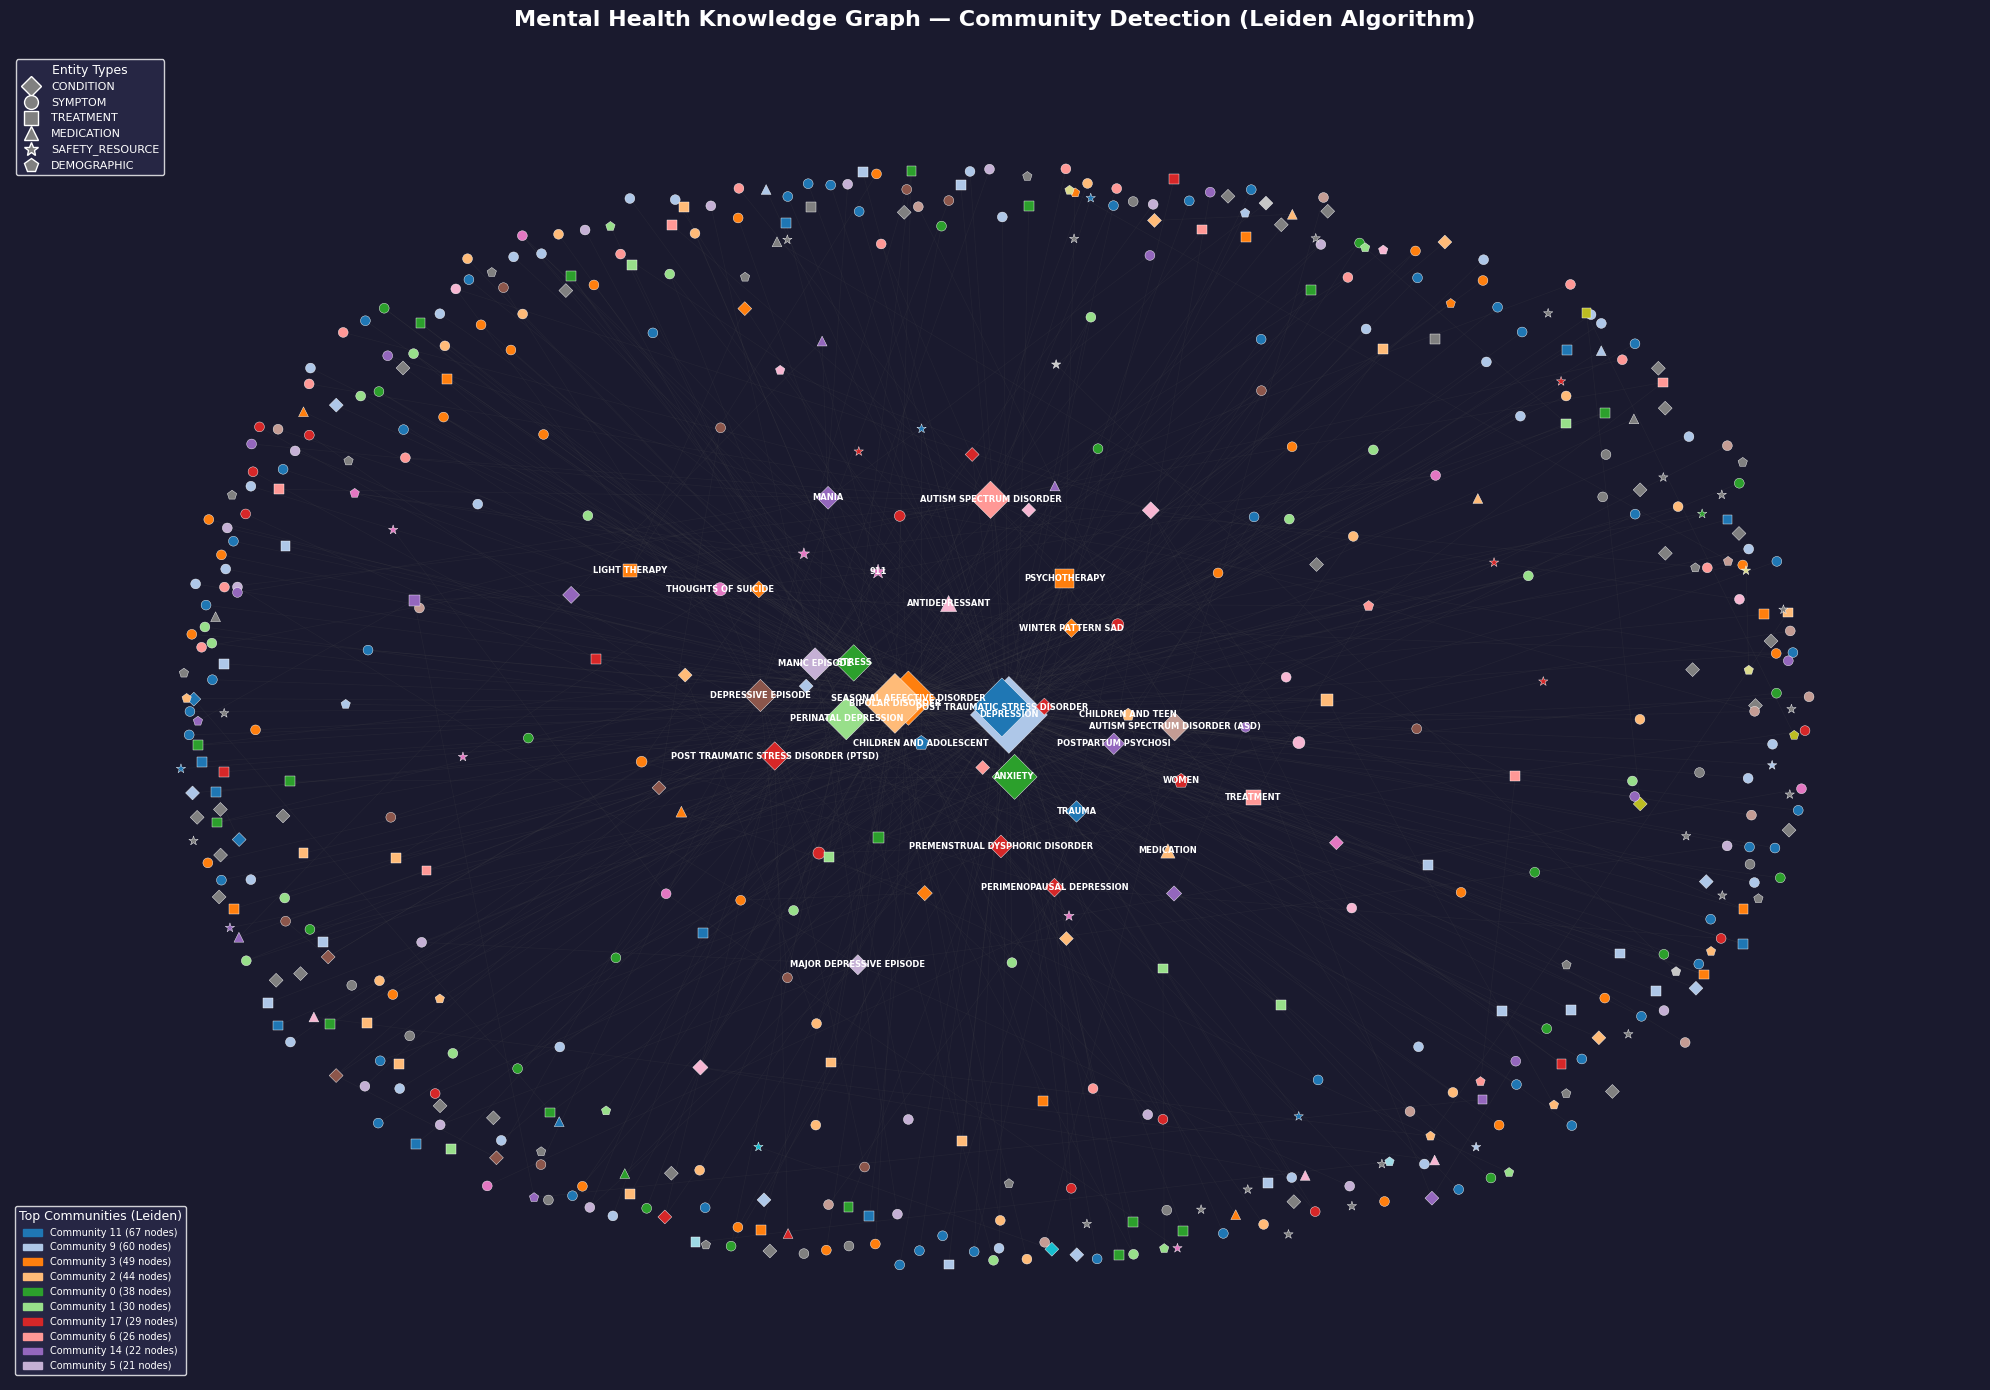


Saved to community_graph_matplotlib.png
Nodes: 539 | Edges: 604 | Communities: 21


In [21]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from llama_index.core.graph_stores.types import EntityNode

G_vis = nx.Graph()
for entity in custom_entities.values():
    G_vis.add_node(entity.id, name=entity.name, label=entity.label)

for rel in custom_relations:
    if rel.source_id in entity_id_to_node and rel.target_id in entity_id_to_node:
        G_vis.add_edge(rel.source_id, rel.target_id, relation=rel.label)

random.seed(42)
comm_ids_sorted = sorted(communities.keys(), key=lambda c: -len(communities[c]))
cmap = plt.cm.get_cmap("tab20", max(len(communities), 20))
community_colors_mpl = {comm_id: cmap(idx % 20) for idx, comm_id in enumerate(comm_ids_sorted)}

node_to_comm = {mid: comm_id for comm_id, member_ids in communities.items() for mid in member_ids}

MARKER_MAP = {
    "CONDITION": "D", "SYMPTOM": "o", "TREATMENT": "s",
    "MEDICATION": "^", "SAFETY_RESOURCE": "*", "DEMOGRAPHIC": "p",
}

print("Computing layout (this may take a moment)...")
pos = nx.spring_layout(G_vis, k=0.5, iterations=50, seed=42)

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.15, edge_color="#555555", width=0.5)

for entity_type, marker in MARKER_MAP.items():
    type_nodes = [n for n in G_vis.nodes()
                  if entity_id_to_node.get(n, EntityNode(name="", label="")).label == entity_type]
    if not type_nodes:
        continue
    type_pos = {n: pos[n] for n in type_nodes if n in pos}
    xs = [type_pos[n][0] for n in type_nodes if n in type_pos]
    ys = [type_pos[n][1] for n in type_nodes if n in type_pos]
    colors_filtered = [community_colors_mpl.get(node_to_comm.get(n, -1), (0.5, 0.5, 0.5, 1.0))
                       for n in type_nodes if n in type_pos]
    sizes_filtered = [max(50, G_vis.degree(n) * 15) for n in type_nodes if n in type_pos]
    ax.scatter(xs, ys, c=colors_filtered, s=sizes_filtered, marker=marker,
               edgecolors="white", linewidths=0.3, zorder=3, label=entity_type)

degree_threshold = sorted([G_vis.degree(n) for n in G_vis.nodes()], reverse=True)
cutoff = degree_threshold[min(25, len(degree_threshold) - 1)] if degree_threshold else 0
labels = {n: entity_id_to_node[n].name for n in G_vis.nodes()
          if n in entity_id_to_node and G_vis.degree(n) >= cutoff}
nx.draw_networkx_labels(G_vis, pos, labels, font_size=6, font_color="white",
                        font_weight="bold", ax=ax)

type_handles = [plt.Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
                            markersize=10, linestyle='None', label=t)
                for t, m in MARKER_MAP.items()]
top_n_legend = min(10, len(comm_ids_sorted))
comm_handles = [mpatches.Patch(color=community_colors_mpl[comm_ids_sorted[i]],
                               label=f"Community {comm_ids_sorted[i]} ({len(communities[comm_ids_sorted[i]])} nodes)")
                for i in range(top_n_legend)]

legend1 = ax.legend(handles=type_handles, loc="upper left", title="Entity Types",
                    fontsize=8, title_fontsize=9, facecolor="#2a2a4a",
                    edgecolor="white", labelcolor="white")
legend1.get_title().set_color("white")
ax.add_artist(legend1)
legend2 = ax.legend(handles=comm_handles, loc="lower left", title="Top Communities (Leiden)",
                    fontsize=7, title_fontsize=9, facecolor="#2a2a4a",
                    edgecolor="white", labelcolor="white")
legend2.get_title().set_color("white")

ax.set_title("Mental Health Knowledge Graph — Community Detection (Leiden Algorithm)",
             fontsize=16, color="white", fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.savefig("community_graph_matplotlib.png", dpi=150,
            facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()
print(f"\nSaved to community_graph_matplotlib.png")
print(f"Nodes: {G_vis.number_of_nodes()} | Edges: {G_vis.number_of_edges()} | Communities: {len(communities)}")

---
## Step 6 — Community Summarization

The LLM generates a natural-language summary for each community cluster.  
These summaries power the **global search** layer of the query engine.

In [22]:
from llama_index.core.llms import ChatMessage
import json
import os

COMM_PROGRESS_FILE = "./checkpoints/community_progress.jsonl"
COMM_SUMMARIES_FILE = "./checkpoints/community_summaries.json"
os.makedirs("./checkpoints", exist_ok=True)

already_done = 0
if os.path.exists(COMM_PROGRESS_FILE):
    with open(COMM_PROGRESS_FILE, "r", encoding="utf-8") as f:
        already_done = sum(1 for line in f if line.strip())
    print(f"Progress file found: {already_done} communities already summarized.")
else:
    print("No community progress file found. Will start from scratch.")

COMM_START_INDEX = None
if COMM_START_INDEX is None:
    COMM_START_INDEX = already_done

if COMM_START_INDEX == 0 and os.path.exists(COMM_PROGRESS_FILE):
    os.remove(COMM_PROGRESS_FILE)
    print("Restart requested - community progress file cleared.")

comm_items = sorted(communities.items(), key=lambda x: -len(x[1]))
print(f"\nSummarizing communities from index {COMM_START_INDEX} / {max(0, len(comm_items)-1)}...\n")

with open(COMM_PROGRESS_FILE, "a", encoding="utf-8") as progress_f:
    for i in range(COMM_START_INDEX, len(comm_items)):
        comm_id, member_ids = comm_items[i]

        members = []
        for mid in member_ids:
            if mid in entity_id_to_node:
                e = entity_id_to_node[mid]
                members.append(f"{e.name} [{e.label}]")

        community_set = set(member_ids)
        internal_rels = []
        for r in custom_relations:
            if r.source_id in community_set and r.target_id in community_set:
                if r.source_id in entity_id_to_node and r.target_id in entity_id_to_node:
                    src_name = entity_id_to_node[r.source_id].name
                    tgt_name = entity_id_to_node[r.target_id].name
                    internal_rels.append(f"({src_name}) -[{r.label}]-> ({tgt_name})")

        if len(members) < 2:
            summary_text = "Skipped: too few valid entities"
        else:
            entities_str = "\n".join(f"- {m}" for m in members)
            relations_str = "\n".join(f"- {r}" for r in internal_rels) if internal_rels else "(no internal relations)"

            system_msg = ChatMessage(
                role="system",
                content=(
                    "You are a medical knowledge graph analyst. Given a cluster of entities and their "
                    "relationships from mental health brochures, write a concise summary (3-5 sentences) "
                    "that describes the main topic, key symptoms/treatments/medications, and relation patterns. "
                    "Be factual and do not add external information."
                ),
            )
            user_msg = ChatMessage(
                role="user",
                content=(
                    f"COMMUNITY_ID: {comm_id}\n\n"
                    f"ENTITIES:\n{entities_str}\n\n"
                    f"RELATIONS:\n{relations_str}"
                ),
            )
            summary_text = llm.chat([system_msg, user_msg]).message.content.strip()

        record = {
            "order_idx": i,
            "community_id": comm_id,
            "size": len(members),
            "entities": members,
            "relations": internal_rels,
            "summary": summary_text,
        }
        progress_f.write(json.dumps(record, ensure_ascii=False) + "\n")
        progress_f.flush()

        print(f"[{i+1}/{len(comm_items)}] Community {comm_id}: summarized ({len(members)} entities)")

community_summaries = {}
with open(COMM_PROGRESS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        rec = json.loads(line)
        community_summaries[rec["community_id"]] = {
            "summary": rec["summary"],
            "entities": rec["entities"],
            "relations": rec["relations"],
            "size": rec["size"],
        }

with open(COMM_SUMMARIES_FILE, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in community_summaries.items()}, f, indent=2, ensure_ascii=False)

print(f"\nGenerated summaries for {len(community_summaries)} communities.")
print(f"Saved summaries to {COMM_SUMMARIES_FILE}")

No community progress file found. Will start from scratch.

Summarizing communities from index 0 / 20...

[1/21] Community 11: summarized (67 entities)
[2/21] Community 9: summarized (60 entities)
[3/21] Community 3: summarized (49 entities)
[4/21] Community 2: summarized (44 entities)
[5/21] Community 0: summarized (38 entities)
[6/21] Community 1: summarized (30 entities)
[7/21] Community 17: summarized (29 entities)
[8/21] Community 6: summarized (26 entities)
[9/21] Community 14: summarized (22 entities)
[10/21] Community 5: summarized (21 entities)
[11/21] Community 8: summarized (16 entities)
[12/21] Community 10: summarized (15 entities)
[13/21] Community 4: summarized (14 entities)
[14/21] Community 15: summarized (14 entities)
[15/21] Community 18: summarized (3 entities)
[16/21] Community 19: summarized (3 entities)
[17/21] Community 20: summarized (3 entities)
[18/21] Community 13: summarized (3 entities)
[19/21] Community 12: summarized (2 entities)
[20/21] Community 16: su

---
## Step 7 — Query Engine (Local + Global + Hybrid)

- **Local search**: triplet-level (specific facts)
- **Global search**: community-summary-level (broad topics)
- **Hybrid**: both combined

In [30]:
from llama_index.core.graph_stores import SimplePropertyGraphStore
from llama_index.core import PropertyGraphIndex
from llama_index.core.llms import ChatMessage

# Rebuild index + create local query engine
print("--- REBUILDING INDEX ---")
graph_store = SimplePropertyGraphStore()
graph_store.upsert_nodes(list(custom_entities.values()))
graph_store.upsert_relations(custom_relations)

index = PropertyGraphIndex.from_existing(
    property_graph_store=graph_store,
    llm=llm
)
local_query_engine = index.as_query_engine()

# Avoid nested event loop issues in notebooks by forcing sync retrieval path.
if hasattr(local_query_engine, "_retriever") and hasattr(local_query_engine._retriever, "use_async"):
    local_query_engine._retriever.use_async = False

print(f"Index rebuilt: {len(custom_entities)} entities, {len(custom_relations)} relations")
print("local_query_engine is ready")

STOPWORDS = {
    "what", "are", "the", "of", "is", "a", "an", "how", "why",
    "in", "for", "to", "and", "or", "do", "does", "did", "can",
    "could", "would", "should", "tell", "me", "about", "give",
    "list", "describe", "explain", "i", "my", "your", "their"
}


def global_query(question, community_summaries, llm, min_score=2, max_communities=8):
    question_lower = question.lower()
    q_words = set(question_lower.split()) - STOPWORDS

    scored = []
    for comm_id, data in community_summaries.items():
        summary = data["summary"].lower()
        entities_text = " ".join(data["entities"]).lower()
        combined = summary + " " + entities_text

        score = sum(1 for w in q_words if w in combined)
        scored.append((comm_id, score, data))

    scored.sort(key=lambda x: -x[1])
    top_communities = [(c, s, d) for c, s, d in scored if s >= min_score][:max_communities]

    if not top_communities:
        print("No communities scored above threshold, using top 3 fallback")
        top_communities = scored[:3]

    context_parts = []
    for comm_id, score, data in top_communities:
        context_parts.append(
            f"[Community {comm_id} | {data['size']} entities | Relevance score: {score}]\n"
            f"{data['summary']}\n"
            f"Key entities: {', '.join(data['entities'][:10])}"
        )
    context = "\n\n---\n\n".join(context_parts)

    system_msg = ChatMessage(
        role="system",
        content=(
            "You are a mental health information assistant. Answer the user's question "
            "based STRICTLY on the community summaries provided below. "
            "Do NOT use any outside knowledge or your own training data. "
            "Every single fact in your answer MUST reference a Community by number "
            "(e.g. 'According to Community 4...'). "
            "If a fact cannot be traced to a specific community, do not include it. "
            "If the summaries do not contain enough information, say: "
            "'The available knowledge graph does not contain sufficient information on this topic.'\n\n"
            f"COMMUNITY SUMMARIES:\n{context}"
        )
    )
    user_msg = ChatMessage(role="user", content=question)

    response = llm.chat([system_msg, user_msg]).message.content.strip()
    return response, top_communities


def hybrid_query(question, community_summaries, local_query_engine, llm):
    print(f"Question: {question}\n")

    MENTAL_HEALTH_KEYWORDS = {
        "depression", "anxiety", "ptsd", "trauma", "bipolar", "schizophrenia",
        "ocd", "adhd", "autism", "phobia", "disorder", "syndrome", "psychiatric",
        "mental", "psychological", "mood", "panic", "stress", "grief", "eating",
        "symptom", "feeling", "emotion", "suicidal", "hallucination", "delusion",
        "insomnia", "fatigue", "worthlessness", "hopeless", "paranoia",
        "therapy", "medication", "treatment", "counseling", "psychiatrist",
        "psychologist", "antidepressant", "cbt", "dbt", "emdr", "diagnosis",
        "suicide", "self-harm", "self harm", "hurt myself", "hurt himself",
        "hurt herself", "end my life", "kill myself", "overdose", "crisis",
    }

    def is_mental_health_query(question: str) -> bool:
        q_lower = question.lower()
        return any(kw in q_lower for kw in MENTAL_HEALTH_KEYWORDS)

    OUT_OF_SCOPE_RESPONSE = (
        "I'm a mental health information assistant and can only answer questions "
        "about mental health conditions, symptoms, treatments, and related topics. "
        "For your question, I'd recommend consulting a general-purpose resource. "
        "Is there anything related to mental health I can help you with?"
    )

    if not is_mental_health_query(question):
        return {
            "answer": OUT_OF_SCOPE_RESPONSE,
            "local_result": "",
            "local_was_useful": False,
            "global_result": "",
            "communities_used": [],
            "out_of_scope": True
        }

    print("Local Search (triplet-level)...")
    local_response = local_query_engine.query(question)
    local_text = str(local_response).strip()

    QUERY_STOPWORDS = {
        "what", "are", "the", "of", "is", "a", "an", "how", "why",
        "in", "for", "to", "and", "or", "do", "does", "did", "can",
        "could", "would", "should", "tell", "me", "about", "give",
        "list", "describe", "explain", "i", "my", "your", "their",
        "symptoms", "treatments", "causes", "effects", "available",
    }
    meaningful_keywords = set(question.lower().split()) - QUERY_STOPWORDS
    local_is_useful = (
        len(meaningful_keywords) > 0 and
        any(kw in local_text.lower() for kw in meaningful_keywords) and
        len(local_text) > 50
    )

    if local_is_useful:
        print("Local result looks relevant")
    else:
        print("Local result appears irrelevant - will downweight in synthesis")

    print("Global Search (community-level)...")
    q_words = set(question.lower().split()) - STOPWORDS
    dynamic_min_score = max(1, len(q_words) // 2)

    global_response, top_comms = global_query(
        question,
        community_summaries,
        llm,
        min_score=dynamic_min_score,
        max_communities=8
    )

    communities_used = [(c[0], c[1]) for c in top_comms]
    print(f"Used communities: {communities_used}\n")

    if local_is_useful:
        synthesis_instruction = (
            "You are a mental health information assistant. Synthesize the following two "
            "responses into a single, comprehensive answer without repetition.\n\n"
            "The LOCAL response comes from specific knowledge graph triplets.\n"
            "The GLOBAL response comes from community-level summaries.\n\n"
            "When citing facts, prefix them with [LOCAL] or [GLOBAL] so the source is clear.\n\n"
            f"LOCAL SEARCH RESULT:\n{local_text}\n\n"
            f"GLOBAL SEARCH RESULT:\n{global_response}"
        )
    else:
        synthesis_instruction = (
            "You are a mental health information assistant. Answer the user's question "
            "based on the following research result. Write a clear, well-structured response.\n\n"
            f"RESEARCH RESULT:\n{global_response}"
        )

    system_msg = ChatMessage(role="system", content=synthesis_instruction)
    user_msg = ChatMessage(role="user", content=question)
    final = llm.chat([system_msg, user_msg]).message.content.strip()

    return {
        "answer": final,
        "local_result": local_text,
        "local_was_useful": local_is_useful,
        "global_result": global_response,
        "communities_used": communities_used
    }


def print_result(result):
    print("=" * 60)
    print("FINAL ANSWER:")
    print("=" * 60)
    print(result["answer"])
    print()
    print(f"Local result used   : {result['local_was_useful']}")
    print(f"Communities used    : {result['communities_used']}")
    print("=" * 60)


print("Query functions ready: global_query(), hybrid_query(), print_result()")

# Ensure the current engine (if already created before this patch) is forced to sync retrieval.
if hasattr(local_query_engine, "_retriever") and hasattr(local_query_engine._retriever, "use_async"):
    local_query_engine._retriever.use_async = False
    print("Forced local_query_engine retriever to use_async=False")

--- REBUILDING INDEX ---
Index rebuilt: 539 entities, 608 relations
local_query_engine is ready
Query functions ready: global_query(), hybrid_query(), print_result()
Forced local_query_engine retriever to use_async=False


### 7b — Run Test Queries

In [31]:
SEP = "=" * 60

import nest_asyncio
nest_asyncio.apply()

# Extra guard in case Step 7 cell wasn't re-run after code updates.
if "local_query_engine" in globals() and hasattr(local_query_engine, "_retriever") and hasattr(local_query_engine._retriever, "use_async"):
    local_query_engine._retriever.use_async = False
    print("Forced local_query_engine retriever to use_async=False")

# Test 1: LOCAL (specific facts)
print(SEP)
print("TEST 1 — LOCAL SEARCH")
print(SEP)
q1 = "What medications are used to treat depression?"
print(f"Q: {q1}")
print(f"A: {local_query_engine.query(q1)}\n")

# Test 2: GLOBAL (broad topic)
print(SEP)
print("TEST 2 — GLOBAL SEARCH")
print(SEP)
q2 = "Compare the treatment approaches for anxiety and depression."
global_result, used_communities = global_query(q2, community_summaries, llm)
print(f"Q: {q2}")
print(f"A: {global_result}")
print(f"Communities used: {[(c[0], c[1]) for c in used_communities]}\n")

# Test 3: HYBRID
print(SEP)
print("TEST 3 — HYBRID SEARCH")
print(SEP)
q3 = "What are the symptoms of PTSD and how is it treated?"
result = hybrid_query(q3, community_summaries, local_query_engine, llm)
print(f"\nQ: {q3}")
print(f"A: {result['answer']}")

Forced local_query_engine retriever to use_async=False
TEST 1 — LOCAL SEARCH
Q: What medications are used to treat depression?
A: Prescribed medication is used to treat depression.

TEST 2 — GLOBAL SEARCH
Q: Compare the treatment approaches for anxiety and depression.
A: Based on the community summaries provided, here is a comparison of the treatment approaches for depression and anxiety:

**Depression Treatments**
According to Community 9, treatment approaches for depression and severe depression include:
*   **Medical Interventions:** Brain stimulation therapy, prescribed medications, and repetitive transcranial magnetic stimulation.
*   **Therapeutic Modalities:** Interpersonal therapy and a collaborative care approach.
*   **Lifestyle Changes:** Regular sleep schedules and social connection.

**Anxiety Treatments**
According to Community 0, treatment approaches for anxiety and stress include:
*   **Lifestyle Modifications:** Healthy eating, regular sleep, and exercise.
*   **Comple

---
## Step 8 — Interactive Graph Visualization (Pyvis)

In [32]:
from pyvis.network import Network
import random



random.seed(42)
community_colors = {comm_id: f"#{random.randint(0, 0xFFFFFF):06x}" for comm_id in communities.keys()}
node_to_community = {mid: comm_id for comm_id, member_ids in communities.items() for mid in member_ids}

SHAPE_MAP = {
    "CONDITION": "diamond", "SYMPTOM": "dot", "TREATMENT": "square",
    "MEDICATION": "triangle", "SAFETY_RESOURCE": "star", "DEMOGRAPHIC": "box",
}

net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=True)
net.barnes_hut(gravity=-5000, central_gravity=0.3, spring_length=150)

for entity in custom_entities.values():
    comm_id = node_to_community.get(entity.id, 0)
    net.add_node(
        entity.id,
        label=entity.name,
        title=f"{entity.name}\nType: {entity.label}\nCommunity: {comm_id}",
        color=community_colors.get(comm_id, "#888888"),
        shape=SHAPE_MAP.get(entity.label, "dot"),
        size=20,
    )

for rel in custom_relations:
    if rel.source_id in entity_id_to_node and rel.target_id in entity_id_to_node:
        net.add_edge(rel.source_id, rel.target_id, title=rel.label, label=rel.label, color="#666666")

output_path = "mental_health_knowledge_graph.html"
net.show(output_path)

print(f"Graph saved to {output_path}")
print(f"Nodes: {len(custom_entities)} | Edges: {len(custom_relations)} | Communities: {len(communities)}")
print("Legend:")
print("  Diamond = CONDITION | Circle = SYMPTOM | Square = TREATMENT")
print("  Triangle = MEDICATION | Star = SAFETY_RESOURCE | Box = DEMOGRAPHIC")
print("  Colors represent different Leiden communities")

mental_health_knowledge_graph.html
Graph saved to mental_health_knowledge_graph.html
Nodes: 539 | Edges: 608 | Communities: 21
Legend:
  Diamond = CONDITION | Circle = SYMPTOM | Square = TREATMENT
  Triangle = MEDICATION | Star = SAFETY_RESOURCE | Box = DEMOGRAPHIC
  Colors represent different Leiden communities


In [35]:
from llama_index.core.graph_stores import SimplePropertyGraphStore
from llama_index.core import PropertyGraphIndex
from llama_index.core.llms import ChatMessage
import re

print("--- Step 8b: Strict QA Test (Before Step 9) ---")

# Bootstrap local query engine if execution order skipped Step 7.
if "local_query_engine" not in globals() or local_query_engine is None:
    print("local_query_engine not found. Building it now...")
    graph_store = SimplePropertyGraphStore()
    graph_store.upsert_nodes(list(custom_entities.values()))
    graph_store.upsert_relations(custom_relations)
    index = PropertyGraphIndex.from_existing(property_graph_store=graph_store, llm=llm)
    local_query_engine = index.as_query_engine()

# Prevent nested async errors in notebooks.
if hasattr(local_query_engine, "_retriever") and hasattr(local_query_engine._retriever, "use_async"):
    local_query_engine._retriever.use_async = False

MENTAL_HEALTH_KEYWORDS = {
    "depression", "anxiety", "ptsd", "trauma", "bipolar", "schizophrenia",
    "ocd", "adhd", "autism", "phobia", "disorder", "syndrome", "psychiatric",
    "mental", "psychological", "mood", "panic", "stress", "grief", "eating",
    "symptom", "feeling", "emotion", "suicidal", "hallucination", "delusion",
    "insomnia", "fatigue", "worthlessness", "hopeless", "paranoia",
    "therapy", "medication", "treatment", "counseling", "psychiatrist",
    "psychologist", "antidepressant", "cbt", "dbt", "emdr", "diagnosis",
    "suicide", "self-harm", "self harm", "hurt myself", "hurt himself",
    "hurt herself", "end my life", "kill myself", "overdose", "crisis",
}

QUERY_STOPWORDS = {
    "what", "are", "the", "of", "is", "a", "an", "how", "why", "in", "for",
    "to", "and", "or", "do", "does", "did", "can", "could", "would", "should",
    "tell", "me", "about", "give", "list", "describe", "explain", "i", "my",
    "your", "their", "with", "from", "that", "this",
}

UNKNOWN_MARKERS = {
    "i don't know",
    "insufficient information",
    "not enough information",
    "does not contain sufficient information",
    "cannot answer from the provided data",
}


def _tokenize(text: str):
    return {
        w for w in re.findall(r"[a-zA-Z][a-zA-Z\-']+", text.lower())
        if w not in QUERY_STOPWORDS and len(w) > 2
    }


def _is_mental_health_query(question: str) -> bool:
    q = question.lower()
    return any(k in q for k in MENTAL_HEALTH_KEYWORDS)


def _safe_local_query(local_engine, question: str) -> str:
    try:
        response = local_engine.query(question)
    except RuntimeError as e:
        if "nested async" in str(e).lower():
            if hasattr(local_engine, "_retriever") and hasattr(local_engine._retriever, "use_async"):
                local_engine._retriever.use_async = False
            response = local_engine.query(question)
        else:
            raise
    return str(response).strip()


def _local_has_evidence(question: str, local_text: str) -> bool:
    if not local_text or len(local_text) < 40:
        return False
    local_lower = local_text.lower()
    if any(marker in local_lower for marker in UNKNOWN_MARKERS):
        return False
    q_words = _tokenize(question)
    overlap = sum(1 for w in q_words if w in local_lower)
    return overlap >= 1


def _get_global_context(question: str, summaries: dict, max_communities: int = 6):
    q_words = _tokenize(question)
    dynamic_min_score = max(1, len(q_words) // 2) if q_words else 1

    scored = []
    for comm_id, data in summaries.items():
        summary = str(data.get("summary", "")).lower()
        entities = " ".join(data.get("entities", [])).lower()
        combined = summary + " " + entities
        score = sum(1 for w in q_words if w in combined)
        scored.append((comm_id, score, data))

    scored.sort(key=lambda x: -x[1])
    top = [(cid, score, data) for cid, score, data in scored if score >= dynamic_min_score][:max_communities]

    if not top:
        return "", [], False

    context_parts = []
    for comm_id, score, data in top:
        context_parts.append(
            f"[Community {comm_id} | score={score} | size={data.get('size', 'n/a')}]\n"
            f"Summary: {data.get('summary', '')}\n"
            f"Entities: {', '.join(data.get('entities', [])[:12])}"
        )

    return "\n\n---\n\n".join(context_parts), top, True


def answer_real_question(question: str, summaries: dict, local_engine, llm):
    if not _is_mental_health_query(question):
        return {
            "answer": "Out of scope: I can only answer mental health questions from this graph.",
            "out_of_scope": True,
            "local_used": False,
            "global_used": False,
            "communities_used": [],
        }

    local_text = _safe_local_query(local_engine, question)
    local_ok = _local_has_evidence(question, local_text)

    global_context, top_communities, global_ok = _get_global_context(question, summaries)

    if not local_ok and not global_ok:
        return {
            "answer": "I don't know based on the current knowledge graph.",
            "out_of_scope": False,
            "local_used": False,
            "global_used": False,
            "communities_used": [],
        }

    evidence_blocks = []
    if local_ok:
        evidence_blocks.append(f"LOCAL EVIDENCE:\n{local_text}")
    if global_ok:
        evidence_blocks.append(f"GLOBAL EVIDENCE:\n{global_context}")
    evidence = "\n\n".join(evidence_blocks)

    system_msg = ChatMessage(
        role="system",
        content=(
            "You are a mental health assistant grounded on a knowledge graph. "
            "Answer ONLY from the evidence provided below. "
            "If the evidence is insufficient, reply exactly: "
            "\"I don't know based on the current knowledge graph.\"\n\n"
            f"{evidence}"
        ),
    )
    user_msg = ChatMessage(role="user", content=question)

    try:
        final_answer = llm.chat([system_msg, user_msg]).message.content.strip()
    except Exception:
        final_answer = "I don't know based on the current knowledge graph."

    if not final_answer:
        final_answer = "I don't know based on the current knowledge graph."

    return {
        "answer": final_answer,
        "out_of_scope": False,
        "local_used": local_ok,
        "global_used": global_ok,
        "communities_used": [(c[0], c[1]) for c in top_communities] if global_ok else [],
    }


# Quick test with real + out-of-scope questions.
test_questions = [
    "What are common symptoms of PTSD and how is it treated?",
    "Which medications are used for bipolar disorder?",
    "Who is Lionel Messi?",
]

for q in test_questions:
    print("\n" + "=" * 70)
    print(f"Q: {q}")
    res = answer_real_question(q, community_summaries, local_query_engine, llm)
    print(f"A: {res['answer']}")
    print(f"local_used={res['local_used']} | global_used={res['global_used']} | out_of_scope={res['out_of_scope']}")
    if res["communities_used"]:
        print(f"communities_used={res['communities_used']}")

--- Step 8b: Strict QA Test (Before Step 9) ---

Q: What are common symptoms of PTSD and how is it treated?
A: Based on the provided knowledge graph, the common symptoms of PTSD include risky or reckless behavior, staying away from certain places, events, or objects (avoidance), and traumatic play. Additional symptoms identified include feeling tense or on edge, irritability and angry outbursts, difficulty sleeping, feelings of guilt, thumb sucking, being very sad or depressed, loss of enjoyment, feeling emotionally numb, and nightmares.

PTSD is treated by support or advocacy groups. Additional treatments include creating a safe and supportive environment, Exposure Therapy, Cognitive Behavioral Therapy (CBT), SSRIs, and primary care providers.
local_used=True | global_used=True | out_of_scope=False
communities_used=[(11, 2), (1, 2), (17, 2), (6, 2), (13, 2), (12, 2)]

Q: Which medications are used for bipolar disorder?
A: Based on the provided knowledge graph, the medications used for